# Egyptian Arabic LLM Post-Training Lab — Data Exploration

## 0. Goal and Scope

**Datasets:**

- **SFT:** `MBZUAI-Paris/Egyptian-SFT-Mixture`
- **DPO:** `HeshamHaroon/arabic-dialect-dpo` (config `egyptian`)

**This notebook answers:** what do the raw datasets contain, how are they structured, what quality issues exist, and are they close to LLaMA-Factory format?

**Exploration only — we do NOT:** preprocess, modify data, define the final schema, apply filtering/cleaning rules, or train.

**Efficiency rule:** streaming + small samples only. No `len()` on full data, no full scans. Where exact counts need a full pass, we state the limitation and use a sample.

## 1. Setup and Efficient Loading

**Answers:** can we access both datasets without a full download? What exact IDs / config / split are used?

- `streaming=True`, `split=train` only.
- DPO config is `egyptian`.
- Later steps sample via `.take(n)` / `islice`, never a full download.

In [8]:
# Step 1: Efficient loading with streaming (no full download, no preprocessing)
from datasets import load_dataset

SFT_DATASET_ID = "MBZUAI-Paris/Egyptian-SFT-Mixture"
DPO_DATASET_ID = "HeshamHaroon/arabic-dialect-dpo"
DPO_CONFIG = "egyptian"
SPLIT = "train"

sft_dataset = load_dataset(SFT_DATASET_ID, split=SPLIT, streaming=True)
dpo_dataset = load_dataset(DPO_DATASET_ID, DPO_CONFIG, split=SPLIT, streaming=True)

# Verify streaming objects only (no iteration over full data here)
print(f"SFT: {SFT_DATASET_ID} | split={SPLIT}")
print(sft_dataset)
print(f"\nDPO: {DPO_DATASET_ID} | config={DPO_CONFIG} | split={SPLIT}")
print(dpo_dataset)

SFT: MBZUAI-Paris/Egyptian-SFT-Mixture | split=train
IterableDataset({
    features: ['messages', 'dataset', 'id', 'length_tokens'],
    num_shards: 10
})

DPO: HeshamHaroon/arabic-dialect-dpo | config=egyptian | split=train
IterableDataset({
    features: ['prompt', 'chosen', 'rejected', 'category', 'language', 'dialect'],
    num_shards: 1
})


## 2. Dataset Splits and Sizes

**Answers:** what splits exist? How large are they? What can we know without downloading?

- Streaming `IterableDataset` has no `len()`; exact row counts come from Hub metadata / builder info.
- Reference (Hub viewer, to confirm below): SFT ~1.82M train / 35.8k test; DPO `egyptian` ~11k train.

In [9]:
# Step 2: splits and sizes without full download
from datasets import load_dataset_builder

print("--- SFT builder info (metadata only) ---")
sft_builder = load_dataset_builder(SFT_DATASET_ID)
print(sft_builder.info.splits)
print("config:", sft_builder.config.name if hasattr(sft_builder.config, "name") else sft_builder.config)

print("\n--- DPO builder info (metadata only) ---")
dpo_builder = load_dataset_builder(DPO_DATASET_ID, DPO_CONFIG)
print(dpo_builder.info.splits)

print("\n--- Streaming objects (no length available) ---")
print("SFT:", sft_dataset)
print("DPO:", dpo_dataset)
try:
    print(len(sft_dataset))
except Exception as e:
    print(f"len() not supported on streaming dataset (expected): {type(e).__name__}: {e}")

--- SFT builder info (metadata only) ---
{'test': SplitInfo(name='test', num_bytes=37235209, num_examples=35838), 'train': SplitInfo(name='train', num_bytes=4805687132.950705, num_examples=1817288)}
config: default

--- DPO builder info (metadata only) ---
{'train': SplitInfo(name='train', num_examples=11038)}

--- Streaming objects (no length available) ---
SFT: IterableDataset({
    features: ['messages', 'dataset', 'id', 'length_tokens'],
    num_shards: 10
})
DPO: IterableDataset({
    features: ['prompt', 'chosen', 'rejected', 'category', 'language', 'dialect'],
    num_shards: 1
})
len() not supported on streaming dataset (expected): TypeError: object of type 'IterableDataset' has no len()


## 3. Columns and Schema

**Answers:** what are the raw columns, feature types, and value types of one row?

- Expected from Hub: SFT `['messages', 'dataset', 'id', 'length_tokens']`; DPO `['prompt', 'chosen', 'rejected', 'category', 'language', 'dialect']`.
- Code below inspects actual `features` instead of assuming.

In [10]:
# Step 3: inspect actual schema (features + one-row key/type check)
print("SFT features:")
print(sft_dataset.features)
print("\nDPO features:")
print(dpo_dataset.features)

sft_one = next(iter(sft_dataset))
dpo_one = next(iter(dpo_dataset))
print("\nSFT one-row keys and value types:")
print({k: type(v).__name__ for k, v in sft_one.items()})
print("\nDPO one-row keys and value types:")
print({k: type(v).__name__ for k, v in dpo_one.items()})

SFT features:
{'messages': List({'content': Value('string'), 'role': Value('string')}), 'dataset': Value('string'), 'id': Value('string'), 'length_tokens': Value('int64')}

DPO features:
{'prompt': Value('string'), 'chosen': Value('string'), 'rejected': Value('string'), 'category': Value('string'), 'language': Value('string'), 'dialect': Value('string')}

SFT one-row keys and value types:
{'messages': 'list', 'dataset': 'str', 'id': 'str', 'length_tokens': 'int'}

DPO one-row keys and value types:
{'prompt': 'str', 'chosen': 'str', 'rejected': 'str', 'category': 'str', 'language': 'str', 'dialect': 'str'}


## 4. Representative Samples

**Answers:** what does a real row look like in each dataset?

- Show 3 truncated rows per dataset only. Full analysis happens in later sections.

In [11]:
# Step 4: show a few raw rows (truncated, no analysis)
def trunc(t, n=600):
    t = str(t)
    return t if len(t) <= n else t[:n] + " ...[truncated]"

print("===== SFT: 3 rows =====")
for i, ex in enumerate(sft_dataset.take(3)):
    print(f"\n--- SFT row {i} | dataset={ex.get('dataset')} | id={ex.get('id')} ---")
    for m in (ex.get("messages") or [])[:4]:
        print(f"[{m.get('role')}]", trunc(m.get("content"), 500))

print("\n\n===== DPO: 3 rows =====")
for i, ex in enumerate(dpo_dataset.take(3)):
    print(f"\n--- DPO row {i} | category={ex.get('category')} ---")
    print("PROMPT:", trunc(ex.get("prompt"), 400))
    print("CHOSEN:", trunc(ex.get("chosen"), 500))
    print("REJECTED:", trunc(ex.get("rejected"), 500))

===== SFT: 3 rows =====

--- SFT row 0 | dataset=tulu-arabic_ai2-adapt-dev/personahub_math_v5_regen_149960 | id=792479 ---
[user] سياسي محلي بيجهز لحملات انتخابية وعايز يزود من فعالية خطابه. هو حدد عاملين مهمين: الوقت اللي هيقضيه في كل موضوع ومستوى تفاعل الجمهور. السياسي قسم خطابه لـ \( n \) موضوع، ولكل موضوع \( i \) (حيث \( i = 1, 2, \ldots, n \))، هو حدد الآتي:

1. \( t_i \): الوقت بالدقايق اللي ناوي يقضيه في الموضوع \( i \).
2. \( e_i(t) \): دالة التفاعل للموضوع \( i \)، اللي بتقيس مستوى تفاعل الجمهور كدالة في الوقت \( t \). دالة التفاعل \( e_i(t) \) معطاة بالمعادلة \( e_i(t) = a_i t e^{-b_i t} \)، حيث \( a_i \) و \( b_ ...[truncated]
[assistant] عشان نحل المسألة دي، لازم نزود دالة التفاعل الكلي مع مراعاة إن مجموع الوقت المستخدم في كل المواضيع يساوي \( T \) دقيقة.

### الخطوة الأولى: كتابة مسألة الأمثلية

التفاعل الكلي \( E \) هو مجموع التفاعل لكل موضوع \( i \):

\[
E = \sum_{i=1}^{n} e_i(t_i)
\]

بما إن دالة التفاعل \( e_i(t) = a_i t e^{-b_i t} \)، التفاعل الكلي ممكن نكتبه كده:

\[

## 5. SFT Message / Role Structure

**Answers:** how many turns per example? Which roles appear? Is the order sane (user-first, assistant-last)? Any empty contents?

- Sample-based (N=200) because a full streaming scan is expensive.

In [12]:
# Step 5: SFT message/role structure on a small sample
from collections import Counter

N = 200
n_turns = []
role_counter = Counter()
first_role = Counter()
last_role = Counter()
empty_content = 0
non_list = 0

for ex in sft_dataset.take(N):
    msgs = ex.get("messages")
    if not isinstance(msgs, list):
        non_list += 1
        continue
    n_turns.append(len(msgs))
    for m in msgs:
        r = m.get("role") if isinstance(m, dict) else None
        role_counter[r] += 1
        c = m.get("content") if isinstance(m, dict) else None
        if not isinstance(c, str) or not c.strip():
            empty_content += 1
    if msgs:
        first_role[msgs[0].get("role") if isinstance(msgs[0], dict) else None] += 1
        last_role[msgs[-1].get("role") if isinstance(msgs[-1], dict) else None] += 1

print(f"sample N={N}, non-list messages rows={non_list}")
print("turns: min", min(n_turns), "max", max(n_turns))
print("turns Counter:", Counter(n_turns).most_common(10))
print("role Counter:", role_counter)
print("first-role Counter:", first_role)
print("last-role Counter:", last_role)
print("empty/blank message contents:", empty_content)

sample N=200, non-list messages rows=0
turns: min 2 max 14
turns Counter: [(2, 177), (4, 7), (14, 6), (6, 5), (3, 4), (10, 1)]
role Counter: Counter({'user': 257, 'assistant': 257, 'system': 4})
first-role Counter: Counter({'user': 196, 'system': 4})
last-role Counter: Counter({'assistant': 200})
empty/blank message contents: 1


## 6. DPO Prompt / Chosen / Rejected Structure

**Answers:** are prompt/chosen/rejected strings? Any empties? Is chosen ever equal to rejected? Which is typically longer?

- Sample-based (N=200). Type check matters because some DPO datasets store lists.

In [13]:
# Step 6: DPO triplet structure on a small sample
N = 200
type_counter = {}
empty_prompt = empty_chosen = empty_rejected = 0
equal_cr = 0
chosen_longer = rejected_longer = 0

for ex in dpo_dataset.take(N):
    p, c, r = ex.get("prompt"), ex.get("chosen"), ex.get("rejected")
    key = (type(p).__name__, type(c).__name__, type(r).__name__)
    type_counter[key] = type_counter.get(key, 0) + 1
    if not isinstance(p, str) or not p.strip():
        empty_prompt += 1
    if not isinstance(c, str) or not c.strip():
        empty_chosen += 1
    if not isinstance(r, str) or not r.strip():
        empty_rejected += 1
    if isinstance(c, str) and isinstance(r, str):
        if c.strip() == r.strip():
            equal_cr += 1
        if len(c) >= len(r):
            chosen_longer += 1
        else:
            rejected_longer += 1

print(f"sample N={N}")
print("(prompt, chosen, rejected) type combos:", type_counter)
print("empty prompt/chosen/rejected:", empty_prompt, empty_chosen, empty_rejected)
print("chosen == rejected:", equal_cr)
print("chosen longer vs rejected longer:", chosen_longer, rejected_longer)

sample N=200
(prompt, chosen, rejected) type combos: {('str', 'str', 'str'): 200}
empty prompt/chosen/rejected: 0 0 0
chosen == rejected: 0
chosen longer vs rejected longer: 200 0


## 7. Missing Values

**Answers:** which fields are null / empty / whitespace-only in practice?

- Sample-based (N=500). Streaming has no exact null-count without a full pass, so this is an estimate.

In [20]:
# Step 7: missing-value estimate on samples (None or blank string)
def is_missing(v):
    if v is None:
        return True
    if isinstance(v, str) and not v.strip():
        return True
    if isinstance(v, list) and len(v) == 0:
        return True
    return False

N = 500
sft_missing = {}
for ex in sft_dataset.take(N):
    for k in ["messages", "dataset", "id", "length_tokens"]:
        if is_missing(ex.get(k)):
            sft_missing[k] = sft_missing.get(k, 0) + 1
print(f"SFT missing counts over N={N}:", sft_missing)

dpo_missing = {}
for ex in dpo_dataset.take(N):
    for k in ["prompt", "chosen", "rejected", "category", "language", "dialect"]:
        if is_missing(ex.get(k)):
            dpo_missing[k] = dpo_missing.get(k, 0) + 1
print(f"DPO missing counts over N={N}:", dpo_missing)
print("Note: exact missing rates require a full pass; treat these as sample estimates.")

SFT missing counts over N=500: {'id': 37, 'length_tokens': 24}
DPO missing counts over N=500: {}
Note: exact missing rates require a full pass; treat these as sample estimates.


## 8. Duplicates

**Answers:** do exact duplicates appear in a sample window? What key would dedup use later?

- Sample-based (N=1000). Global dedup would need a full pass + a defined key (`id` vs text hash); we only flag the signal here.

In [15]:
# Step 8: duplicate signal on samples only (no global dedup decision)
N = 1000
seen_ids = set()
dup_ids = 0
seen_sft_text = set()
dup_sft_text = 0
for ex in sft_dataset.take(N):
    _id = ex.get("id")
    if _id in seen_ids:
        dup_ids += 1
    seen_ids.add(_id)
    msgs = ex.get("messages") or []
    first_user = ""
    for m in msgs:
        if isinstance(m, dict) and m.get("role") == "user":
            first_user = (m.get("content") or "")[:500]
            break
    if first_user in seen_sft_text:
        dup_sft_text += 1
    seen_sft_text.add(first_user)
print(f"SFT N={N}: duplicate id hits={dup_ids}, duplicate first-user-text(500ch) hits={dup_sft_text}")

seen_prompt = set()
dup_prompt = 0
for ex in dpo_dataset.take(N):
    p = (ex.get("prompt") or "")[:1000]
    if p in seen_prompt:
        dup_prompt += 1
    seen_prompt.add(p)
print(f"DPO N={N}: duplicate prompt(1000ch) hits={dup_prompt}")
print("Limitation: full-dataset duplicate rate needs a full pass; keys for later dedup are still open.")

SFT N=1000: duplicate id hits=87, duplicate first-user-text(500ch) hits=3
DPO N=1000: duplicate prompt(1000ch) hits=0
Limitation: full-dataset duplicate rate needs a full pass; keys for later dedup are still open.


## 9. Text / Token Length Distributions

**Answers:** how long are inputs and responses? Are there extreme outliers?

- Char + word counts on N=500 per dataset; SFT also checks the existing `length_tokens` field.
- No tokenizer is loaded here (that would add downloads); exact model-token lengths are a preprocessing decision.

SFT total-chars n=500 min=27 p50=1109 p90=3151 p99=5217 max=5743
SFT length_tokens field n=476 min=26 p50=398 p90=1348 p99=1862 max=2038
DPO prompt chars n=500 min=14 p50=39 p90=53 p99=63 max=71
DPO chosen chars n=500 min=227 p50=1257 p90=1564 p99=1801 max=1968
DPO rejected chars n=500 min=123 p50=263 p90=310 p99=349 max=390


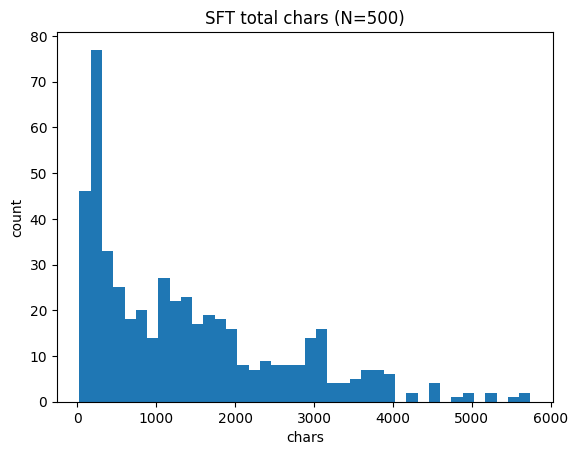

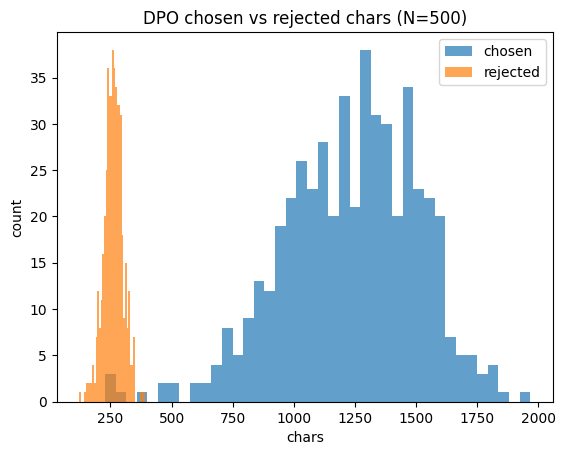

In [16]:
# Step 9: length distributions on samples
import matplotlib.pyplot as plt

def stats(xs, name):
    xs = sorted(xs)
    n = len(xs)
    def q(p):
        return xs[min(n - 1, int(p * n))]
    print(f"{name} n={n} min={xs[0]} p50={q(0.5)} p90={q(0.9)} p99={q(0.99)} max={xs[-1]}")
    return xs

N = 500
sft_total_chars, sft_field_tokens = [], []
for ex in sft_dataset.take(N):
    text = " ".join([(m.get("content") or "") for m in (ex.get("messages") or []) if isinstance(m, dict)])
    sft_total_chars.append(len(text))
    if isinstance(ex.get("length_tokens"), int):
        sft_field_tokens.append(ex["length_tokens"])
sft_total_chars = stats(sft_total_chars, "SFT total-chars")
if sft_field_tokens:
    stats(sft_field_tokens, "SFT length_tokens field")

dpo_p, dpo_c, dpo_r = [], [], []
for ex in dpo_dataset.take(N):
    dpo_p.append(len(ex.get("prompt") or ""))
    dpo_c.append(len(ex.get("chosen") or ""))
    dpo_r.append(len(ex.get("rejected") or ""))
stats(dpo_p, "DPO prompt chars")
stats(dpo_c, "DPO chosen chars")
stats(dpo_r, "DPO rejected chars")

plt.figure()
plt.hist(sft_total_chars, bins=40)
plt.title(f"SFT total chars (N={N})")
plt.xlabel("chars"); plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(dpo_c, bins=40, alpha=0.7, label="chosen")
plt.hist(dpo_r, bins=40, alpha=0.7, label="rejected")
plt.title(f"DPO chosen vs rejected chars (N={N})")
plt.xlabel("chars"); plt.ylabel("count")
plt.legend()
plt.show()

## 10. Metadata: Language / Dialect / Category

**Answers:** what values exist in `dataset` (SFT) and `category/language/dialect` (DPO)? Is DPO really Egyptian-only?

- Counters on N=2000 (SFT `dataset`) and N=1000 (DPO fields); small enough for streaming.

In [17]:
# Step 10: metadata distributions on samples
from collections import Counter

sft_src = Counter()
for ex in sft_dataset.take(2000):
    sft_src[ex.get("dataset")] += 1
print("SFT `dataset` distinct:", len(sft_src))
for k, v in sft_src.most_common(20):
    print(f"  {v:5d}  {k}")

from collections import Counter as _C
cat, lang, dial = _C(), _C(), _C()
for ex in dpo_dataset.take(1000):
    cat[ex.get("category")] += 1
    lang[ex.get("language")] += 1
    dial[ex.get("dialect")] += 1
print("\nDPO category:", dict(cat))
print("DPO language:", dict(lang))
print("DPO dialect:", dict(dial))

SFT `dataset` distinct: 58
    272  wildchat-latin
    169  aya_dialogue
    155  tulu-arabic_ai2-adapt-dev/personahub_math_v5_regen_149960
     97  benchmarks_ar
     97  tulu-arabic_ai2-adapt-dev/evol_codealpaca_heval_decontaminated
     96  short-translation_egy_msa
     74  tulu-arabic_ai2-adapt-dev/flan_v2_converted
     69  tulu-arabic_ai2-adapt-dev/numinamath_tir_math_decontaminated
     57  tulu-arabic_allenai/tulu-3-sft-personas-math-grade
     56  tulu-arabic_cot
     49  benchmarks_ltn
     47  ultrachat-arabic
     46  tulu-arabic_ai2-adapt-dev/tulu_v3.9_open_math_2_gsm8k_50k
     45  long-translation_wikipedia
     44  tulu-latin_ai2-adapt-dev/tulu_v3.9_wildchat_100k
     39  tulu-arabic_ai2-adapt-dev/personahub_code_v2_34999
     37  short-translation_arzen
     35  tulu-latin_sharegpt
     35  transliteration_efc
     34  short-translation_oasst2

DPO category: {'customer_service': 90, 'health_fitness': 90, 'parenting': 73, 'education': 100, 'daily_life': 76, 'religion_e

## 11. Data Quality Issues (flags only, no cleaning)

**Answers:** what noise should preprocessing consider later?

- Heuristics on N=500: null ids, leaked chat tokens, code/math blocks, Franco-Latin vs Arabic script, extreme lengths.

In [18]:
# Step 11: flag quality signals only (do not clean)
import re

N = 500
null_id = 0
leaked_token = 0
code_block = 0
latin_heavy = 0
checked = 0
leak_pat = re.compile(r"(<\|.*?\|> |### Instruction|### Response)")
for ex in sft_dataset.take(N):
    checked += 1
    if ex.get("id") is None:
        null_id += 1
    text = " ".join([(m.get("content") or "") for m in (ex.get("messages") or []) if isinstance(m, dict)])
    if leak_pat.search(text):
        leaked_token += 1
    if "```" in text:
        code_block += 1
    latin = sum(1 for ch in text[:1000] if ("a" <= ch.lower() <= "z"))
    if latin > 500:
        latin_heavy += 1
print(f"SFT N={checked}: null_id={null_id}, leaked_chat_tokens={leaked_token}, code_fences={code_block}, latin_heavy_first1k={latin_heavy}")

checked = generic_rejected = 0
for ex in dpo_dataset.take(N):
    checked += 1
    r = ex.get("rejected") or ""
    if "ابحث على الإنترنت" in r or "يمكنك البحث على الإنترنت" in r:
        generic_rejected += 1
print(f"DPO N={checked}: generic 'search the internet' rejected={generic_rejected}")
print("Note: script mix (Arabic vs Franco) and translation/code/math slices need deeper sampling in preprocessing.")

SFT N=500: null_id=37, leaked_chat_tokens=0, code_fences=67, latin_heavy_first1k=85
DPO N=500: generic 'search the internet' rejected=444
Note: script mix (Arabic vs Franco) and translation/code/math slices need deeper sampling in preprocessing.


## 12. LLaMA-Factory Suitability Check (read-only)

**Answers:** how close are the raw formats to what LLaMA-Factory expects? What gaps remain?

- SFT `messages` with `role/content` is close to ShareGPT-style; DPO `prompt/chosen/rejected` strings are close to DPO pairwise format.
- No conversion is done here; we only measure validity on N=200.

In [19]:
# Step 12: read-only format check (no conversion, no schema decision)
N = 200
sft_ok = sft_bad_role = sft_bad_order = 0
for ex in sft_dataset.take(N):
    msgs = ex.get("messages")
    if not isinstance(msgs, list) or not msgs:
        sft_bad_role += 1
        continue
    roles = [m.get("role") for m in msgs if isinstance(m, dict)]
    if any(r not in ("system", "user", "assistant") for r in roles):
        sft_bad_role += 1
        continue
    if roles[0] != "user" or roles[-1] != "assistant":
        sft_bad_order += 1
        continue
    sft_ok += 1
print(f"SFT N={N}: valid user-first/assistant-last with known roles={sft_ok}, bad roles/empty={sft_bad_role}, order issues={sft_bad_order}")

dpo_ok = 0
for ex in dpo_dataset.take(N):
    p, c, r = ex.get("prompt"), ex.get("chosen"), ex.get("rejected")
    if all(isinstance(x, str) and x.strip() for x in (p, c, r)) and c.strip() != r.strip():
        dpo_ok += 1
print(f"DPO N={N}: valid string triplet with chosen!=rejected={dpo_ok}")
print("Gaps to decide later: system-role handling, multi-turn SFT mapping, DPO prompt-vs-messages mapping, tokenizer max-length.")

SFT N=200: valid user-first/assistant-last with known roles=196, bad roles/empty=0, order issues=4
DPO N=200: valid string triplet with chosen!=rejected=200
Gaps to decide later: system-role handling, multi-turn SFT mapping, DPO prompt-vs-messages mapping, tokenizer max-length.


## 13. Observations and Open Questions for Preprocessing

**Exploration results (confirm by running cells 1-12 above):**

- SFT streams with `messages/dataset/id/length_tokens` over ~10 shards; Hub reports ~1.82M train rows, 63 `dataset` sources (translation, math, code, dialogue, benchmarks).
- DPO `egyptian` streams with `prompt/chosen/rejected/category/language/dialect`; Hub reports ~11k train rows, 12 categories, `ar-EG` / `egyptian_arabic` only in this config.
- SFT mixes Arabic script and Franco-Latin; DPO chosen is Egyptian-dialect rich while rejected often looks generic MSA (`search the internet` pattern).
- Known flags: some SFT `id=None` (benchmark rows), leaked chat tokens, code fences, very short translation pairs vs very long math reasoning; DPO chosen usually longer than rejected.
- Format closeness: SFT `messages` is near ShareGPT-style; DPO string triplets are near pairwise DPO. Multi-turn, system-role, and tokenizer-length mapping are still open.

**Data-quality issues to investigate later:**

- Script mix ratio (Arabic vs Franco) and whether to keep both.
- Translation-heavy slices vs open-ended dialogue balance.
- Null ids, empty contents, leaked tokens, code/math outliers.
- DPO generic-rejected pattern and chosen-vs-rejected margin.
- Within-sample duplicates; global dedup needs a full pass.

**Decisions explicitly left for preprocessing (not made here):**

1. Final SFT schema and role mapping (system handling, multi-turn).
2. Final DPO schema (plain prompt vs messages).
3. Tokenizer and max-length / truncation rule.
4. Filtering rules (length, language, quality, category balance).
5. Dedup key (`id` vs text hash) and scope (within-sample vs global).
6. Train/eval split strategy for the pipeline.
7. LLaMA-Factory dataset-info configuration.

End of exploration. Do not proceed to preprocessing in this notebook.